## Summary

**Problem:** Predict which healthcare claims are fraudulent. Fraud is only 8.3% of the 10,000 claims, so accuracy is misleading (a model that never flags fraud is 91.7% accurate). 

I used PR-AUC instead, which focuses on finding the rare fraud cases.

**Data decisions**
- Recovered all 350 missing provider specialties from each provider's other claims, filled missing insurance types with "Unknown," and filled missing prior visits with the training-set median.
- Removed `Claim_Status` and `Approved_Amount` to prevent leakage, since both are decided after a claim is reviewed.

**EDA findings**
- Grouped features into patient, visit, claim, and provider categories. Patient and visit features, provider specialty, and date features all sat near the 8.3% baseline.
- Three features stood out, all about billing behavior: **filing delay, claim amount, and provider volume.**
- Fraud appeared most often in the most common diagnosis-procedure pairs, but at near-baseline rates. Unusual fraud rates showed up only where sample sizes were too small to be reliable.
- The data shows signs of being synthetic: every claim filed within 1 day is fraud, no claim filed after 6 days is, and length of stay is unrealistically uniform.

**Modeling**
- Started with Logistic Regression, then added class weighting so the model would take rare fraud seriously, then compared tree-based models with 5-fold cross-validation.
- XGBoost won. Tuning (a slower learning rate and fewer trees) raised cross-validated PR-AUC from 0.759 to 0.790.
- **Test PR-AUC: 0.798** (vs. a 0.083 random baseline), matching cross-validation.

**Honest check:** Retrained without filing delay, PR-AUC fell from 0.759 to 0.231. Filing delay drives most of the performance, but the other features still score almost 3x the baseline. 

Permutation importance confirmed the ranking: filing delay, then claim amount, then provider volume.

**Business impact:** Assuming a $50 review cost, the cost-optimized cutoff (0.61) catches 96% of fraud for $33,611 on the test set. 

That's 87% cheaper than paying all fraud and 78% cheaper than reviewing every claim.

**Limitations:** Synthetic data, so the near-perfect filing-delay rule wouldn't appear in real claims. The $50 review cost is an assumption.

## 1. Setup and Data Loading

The dataset is downloaded from Kaggle with `kagglehub` and loaded into a DataFrame.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nudratabbas/healthcare-fraud-detection-dataset")

print("Path to dataset files:", path)

/Users/longphan1912/Downloads/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/longphan1912/.cache/kagglehub/datasets/nudratabbas/healthcare-fraud-detection-dataset/versions/1


In [2]:
files = os.listdir(path)
print(files)

['healthcare_fraud_detection.csv']


In [3]:
df = pd.read_csv(f"{path}/{files[0]}")
df.shape

(10000, 20)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_Age,10000.0,49.755000,17.910144,1.00,37.750,50.000,62.0000,95.00
Procedure_Code,10000.0,86905.211700,14965.324960,36415.00,80053.000,93000.000,99213.0000,99214.00
Claim_Amount,10000.0,572.804406,406.202437,60.21,305.205,461.225,711.3650,6590.70
Approved_Amount,10000.0,475.514157,323.257165,50.35,257.200,388.370,598.3475,4270.89
Days_Between_Service_and_Claim,10000.0,14.413800,8.489875,0.00,7.000,14.000,22.0000,29.00
Number_of_Claims_Per_Provider_Monthly,10000.0,68.628000,14.905872,42.00,60.000,66.000,72.0000,144.00
Is_Fraud,10000.0,0.082900,0.275745,0.00,0.000,0.000,0.0000,1.00
Length_of_Stay,10000.0,2.199300,1.710460,0.00,1.000,2.000,3.0000,5.00
Chronic_Condition_Flag,10000.0,0.292000,0.454705,0.00,0.000,0.000,1.0000,1.00
Prior_Visits_12m,9650.0,3.026425,1.722789,0.00,2.000,3.000,4.0000,12.00


In [5]:
df.head()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  str    
 1   Claim_ID                               10000 non-null  str    
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  str    
 4   Diagnosis_Code                         10000 non-null  str    
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   str    
 9   Claim_Submission_Date                  10000 non-null  str    
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Number_of_Clai

The dataset has **10,000 claims and 20 columns**: patient details (age, gender, state, chronic condition, prior visits), visit details (visit type, length of stay, diagnosis and procedure codes), billing details (claim amount, approved amount, filing delay, claim status), provider details (ID, specialty, monthly claim volume), and the fraud label (`Is_Fraud`).

## 2. Data Cleaning

### Fixing Column Types
- `Procedure_Code` is stored as a number, but it's really a category (code 99214 isn't "more" than 36415), so I convert it to text.
- `Claim_Submission_Date` is converted to a date, and I pull out the month and day of week. These repeat every year, so any pattern could apply to future claims. A specific month-year never repeats, so it's only used for EDA.

In [7]:
# Convert Procedure_Code to text, so it's treated as a category rather than a number:
df['Procedure_Code'] = df['Procedure_Code'].astype(str)

In [8]:
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'])
df['Submission_Month'] = df['Claim_Submission_Date'].dt.month
df['Submission_DayOfWeek'] = df['Claim_Submission_Date'].dt.dayofweek   # Monday = 0
df['Month_Year'] = df['Claim_Submission_Date'].dt.strftime('%Y-%m')

### Missing Values, Duplicates, and Class Balance

In [9]:
df.isnull().sum()

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
Submission_Month                           0
Submission_DayOfWeek                       0
Month_Year

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Is_Fraud'].value_counts(normalize=True)

Is_Fraud
0    0.9171
1    0.0829
Name: proportion, dtype: float64

- **Missing values:** 350 each in `Insurance_Type`, `Provider_Specialty`, and `Prior_Visits_12m`. Every other column is complete.
- **Duplicates:** none.
- **Class balance:** only **8.3% of claims are fraud**. This is a severe imbalance, so accuracy will be misleading. A model that never flags fraud would already be 91.7% accurate.

In [12]:
null_cols = ['Insurance_Type', 'Provider_Specialty', 'Prior_Visits_12m']
# Are the nulls on the same rows?
print("Rows with any null:", df[null_cols].isnull().any(axis=1).sum())
print("Rows with all three null:", df[null_cols].isnull().all(axis=1).sum())

for col in null_cols:
    rates = df.groupby(df[col].isnull())['Is_Fraud'].mean()
    print(f"For {col}, the present and missing fraud rates are {rates[False]:.2%} and {rates[True]:.2%}, respectively")

Rows with any null: 1011
Rows with all three null: 2
For Insurance_Type, the present and missing fraud rates are 8.33% and 7.14%, respectively
For Provider_Specialty, the present and missing fraud rates are 8.28% and 8.57%, respectively
For Prior_Visits_12m, the present and missing fraud rates are 8.29% and 8.29%, respectively


Nulls (350 rows per column) were scattered across 1,011 rows. The fraud rates are nearly identical whether values are missing or present, so the data appears missing at random. Values are filled inside the pipeline rather than dropped.

### Provider Specialty

In [13]:
print(df['Provider_Specialty'].unique().tolist())

['Cardiology', 'General Practice', 'Pulmonology', 'Orthopedics', nan, 'Internal Medicine', 'Neurology']


In [14]:
specialties_per_provider = df.dropna(subset=['Provider_Specialty']).groupby('Provider_ID')['Provider_Specialty']
print("Providers with more than one specialty:", (specialties_per_provider.nunique() > 1).sum(), "of", len(specialties_per_provider.nunique()))

Providers with more than one specialty: 0 of 300


In [15]:
missing_specialty_sample = df.loc[df['Provider_Specialty'].isna(), ['Provider_ID', 'Claim_ID', 'Provider_Specialty']].head(20)
provider_ids_sample = missing_specialty_sample['Provider_ID'].unique().tolist()
print(df.loc[
            df['Provider_ID'].isin(provider_ids_sample),\
            ['Provider_ID', 'Claim_ID', 'Provider_Specialty']
      ].sort_values(by='Provider_ID')
      .drop_duplicates(subset=['Provider_ID', 'Provider_Specialty'])
      .reset_index(drop=True))

   Provider_ID  Claim_ID Provider_Specialty
0        P0015  C0000284  Internal Medicine
1        P0015  C0000545                NaN
2        P0064  C0000056   General Practice
3        P0064  C0000242                NaN
4        P0071  C0000007                NaN
5        P0071  C0000110          Neurology
6        P0090  C0000140                NaN
7        P0090  C0000564         Cardiology
8        P0112  C0000040        Orthopedics
9        P0112  C0000299                NaN
10       P0116  C0000032                NaN
11       P0116  C0000084   General Practice
12       P0136  C0000014                NaN
13       P0136  C0000167         Cardiology
14       P0139  C0000035                NaN
15       P0139  C0000240   General Practice
16       P0143  C0000186                NaN
17       P0143  C0000364        Pulmonology
18       P0175  C0000090         Cardiology
19       P0175  C0000523                NaN
20       P0176  C0000023                NaN
21       P0176  C0000857  Intern

All 300 providers have exactly one specialty across their claims, so the 350 missing specialties were recovered from each provider's other claims rather than filled with a placeholder.

In [16]:
df['Provider_Specialty'] = df['Provider_Specialty'].fillna(df['Provider_ID'].map(specialties_per_provider.first()))
print("Count of null values on Provider_Specialty:", df['Provider_Specialty'].isnull().sum())

Count of null values on Provider_Specialty: 0


### Insurance Type

In [17]:
print(df['Insurance_Type'].unique().tolist())

['Medicaid', 'Self-Pay', 'Private', 'Medicare', nan]


In [18]:
df['Insurance_Type'] = df['Insurance_Type'].fillna('Unknown')
print("Count of null values on Insurance_Type:", df['Insurance_Type'].isnull().sum())

Count of null values on Insurance_Type: 0


Missing insurance types are filled with "Unknown." Insurance belongs to the patient, and the dataset has no patient ID to link a patient's claims, so the real value can't be recovered. After one-hot encoding, "Unknown" becomes its own column, which works as a missing-value flag.

In [19]:
print(df['Prior_Visits_12m'].unique().tolist())

[2.0, 3.0, 5.0, 4.0, 1.0, 0.0, nan, 6.0, 7.0, 8.0, 9.0, 12.0, 11.0, 10.0]


### Prior Visits

`Prior_Visits_12m` is left with its missing values for now. They're filled with the **training-set median** inside the modeling pipeline, so the test set never influences the fill value.

In [20]:
df.columns

Index(['Provider_ID', 'Claim_ID', 'Patient_Age', 'Patient_Gender',
       'Diagnosis_Code', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount',
       'Insurance_Type', 'Claim_Submission_Date',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Is_Fraud', 'Length_of_Stay',
       'Visit_Type', 'Chronic_Condition_Flag', 'Prior_Visits_12m',
       'Submission_Month', 'Submission_DayOfWeek', 'Month_Year'],
      dtype='str')

In [21]:
#cardinality check
print(f"Number of unique providers: {df['Provider_ID'].nunique()}")
print(f"Number of unique claims: {df['Claim_ID'].nunique()}")
print(f"Number of diagnosis codes: {df['Diagnosis_Code'].nunique()}")
print(f"Number of procedure codes: {df['Procedure_Code'].nunique()}")
print(f"Number of insurance types: {df['Insurance_Type'].nunique()}")
print(f"Number of visit types: {df['Visit_Type'].nunique()}")

Number of unique providers: 300
Number of unique claims: 10000
Number of diagnosis codes: 10
Number of procedure codes: 9
Number of insurance types: 5
Number of visit types: 3


**Cardinality check:** `Claim_ID` is unique for every claim, so it can't teach any pattern. `Provider_ID` has 300 values, so a model could just memorize which providers are risky, which wouldn't work for new providers. Both are excluded from modeling. Diagnosis codes (10), procedure codes (9), insurance types (5), and visit types (3) are small enough to one-hot encode.

## 3. Leakage Checks

**Leakage** means giving a model information it wouldn't have when it actually makes a prediction. A fraud model scores a claim **when it's submitted**, before anyone reviews it. `Claim_Status` and `Approved_Amount` are both decided *during* review, so they're suspects.

In [22]:
pd.crosstab(df['Claim_Status'], df['Is_Fraud'], normalize='index').round(3)

Is_Fraud,0,1
Claim_Status,,
Approved,0.978,0.022
Pending,0.773,0.227
Rejected,0.769,0.231


Approved claims are 2.2% fraud, while Pending and Rejected are about 23%.

In [23]:
df['Approval_Ratio'] = df['Approved_Amount'] / df['Claim_Amount']
print(df.groupby('Is_Fraud')['Approval_Ratio'].describe().round(3))

           count   mean    std   min    25%    50%    75%  max
Is_Fraud                                                      
0         9171.0  0.876  0.072  0.75  0.814  0.876  0.939  1.0
1          829.0  0.547  0.144  0.30  0.429  0.542  0.677  0.8


Approval ratios barely overlap: non-fraud claims range from 0.75 to 1.0, and fraud claims from 0.30 to 0.80.

Claim_Status and Approved_Amount are set during claim review, after the point where a fraud model would score a claim, so both are excluded to avoid target leakage.

## 4. Exploratory Data Analysis

### Provider Concentration
Which providers have the highest fraud rates? `sum` counts each provider's fraud claims, `count` is their total claims, and `mean` is their fraud rate.

Providers with few claims can show high fraud rates by chance (for example, 3 fraud claims out of 15 is 20%), so fraud rates here are read alongside each provider's claim count. 

Rather than using individual providers, the model uses provider **volume** (`Number_of_Claims_Per_Provider_Monthly`), which works for new providers too.

In [24]:
provider_fraud = df.groupby('Provider_ID')['Is_Fraud'].agg(['sum', 'count', 'mean'])
provider_fraud.columns = ['Fraud_Count', 'Claims_Count', 'Fraud_Rate']

top_25_providers_w_fraud = provider_fraud.sort_values(
    by=['Fraud_Rate', 'Claims_Count'], ascending=False
).head(25)

(top_25_providers_w_fraud.style
    .format({'Fraud_Rate': '{:.1%}'})
    .background_gradient(subset=['Fraud_Count'], cmap='Reds')
    .bar(subset=['Fraud_Rate'], color='#F5B7B1')
    .set_properties(subset=['Fraud_Rate'], **{'color': 'white'})
    .set_caption('Top 25 Providers by Fraud Rate')
)

,Fraud_Count,Claims_Count,Fraud_Rate
Provider_ID,,,
P0086,16,38,42.1%
P0159,7,20,35.0%
P0110,15,45,33.3%
P0104,11,34,32.4%
P0223,14,44,31.8%
P0293,10,33,30.3%
P0255,8,28,28.6%
P0027,10,37,27.0%
P0101,9,36,25.0%


### Fraud Rate by Feature Group

To answer one question, *what separates fraud from normal claims?*, I grouped features into four categories (patient, visit, claim, and provider) and compared each feature's fraud rate against the 8.3% baseline.

In [25]:
features = {
    "Patient": ['Patient_Age', 'Patient_Gender', 'Patient_State', 'Chronic_Condition_Flag', 'Prior_Visits_12m', 'Insurance_Type'],
    "Visit": ['Visit_Type', 'Length_of_Stay', 'Diagnosis_Code', 'Procedure_Code'],
    "Claim": ['Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Submission_Month', 'Submission_DayOfWeek'],
    "Provider": ['Provider_Specialty', 'Number_of_Claims_Per_Provider_Monthly']
}

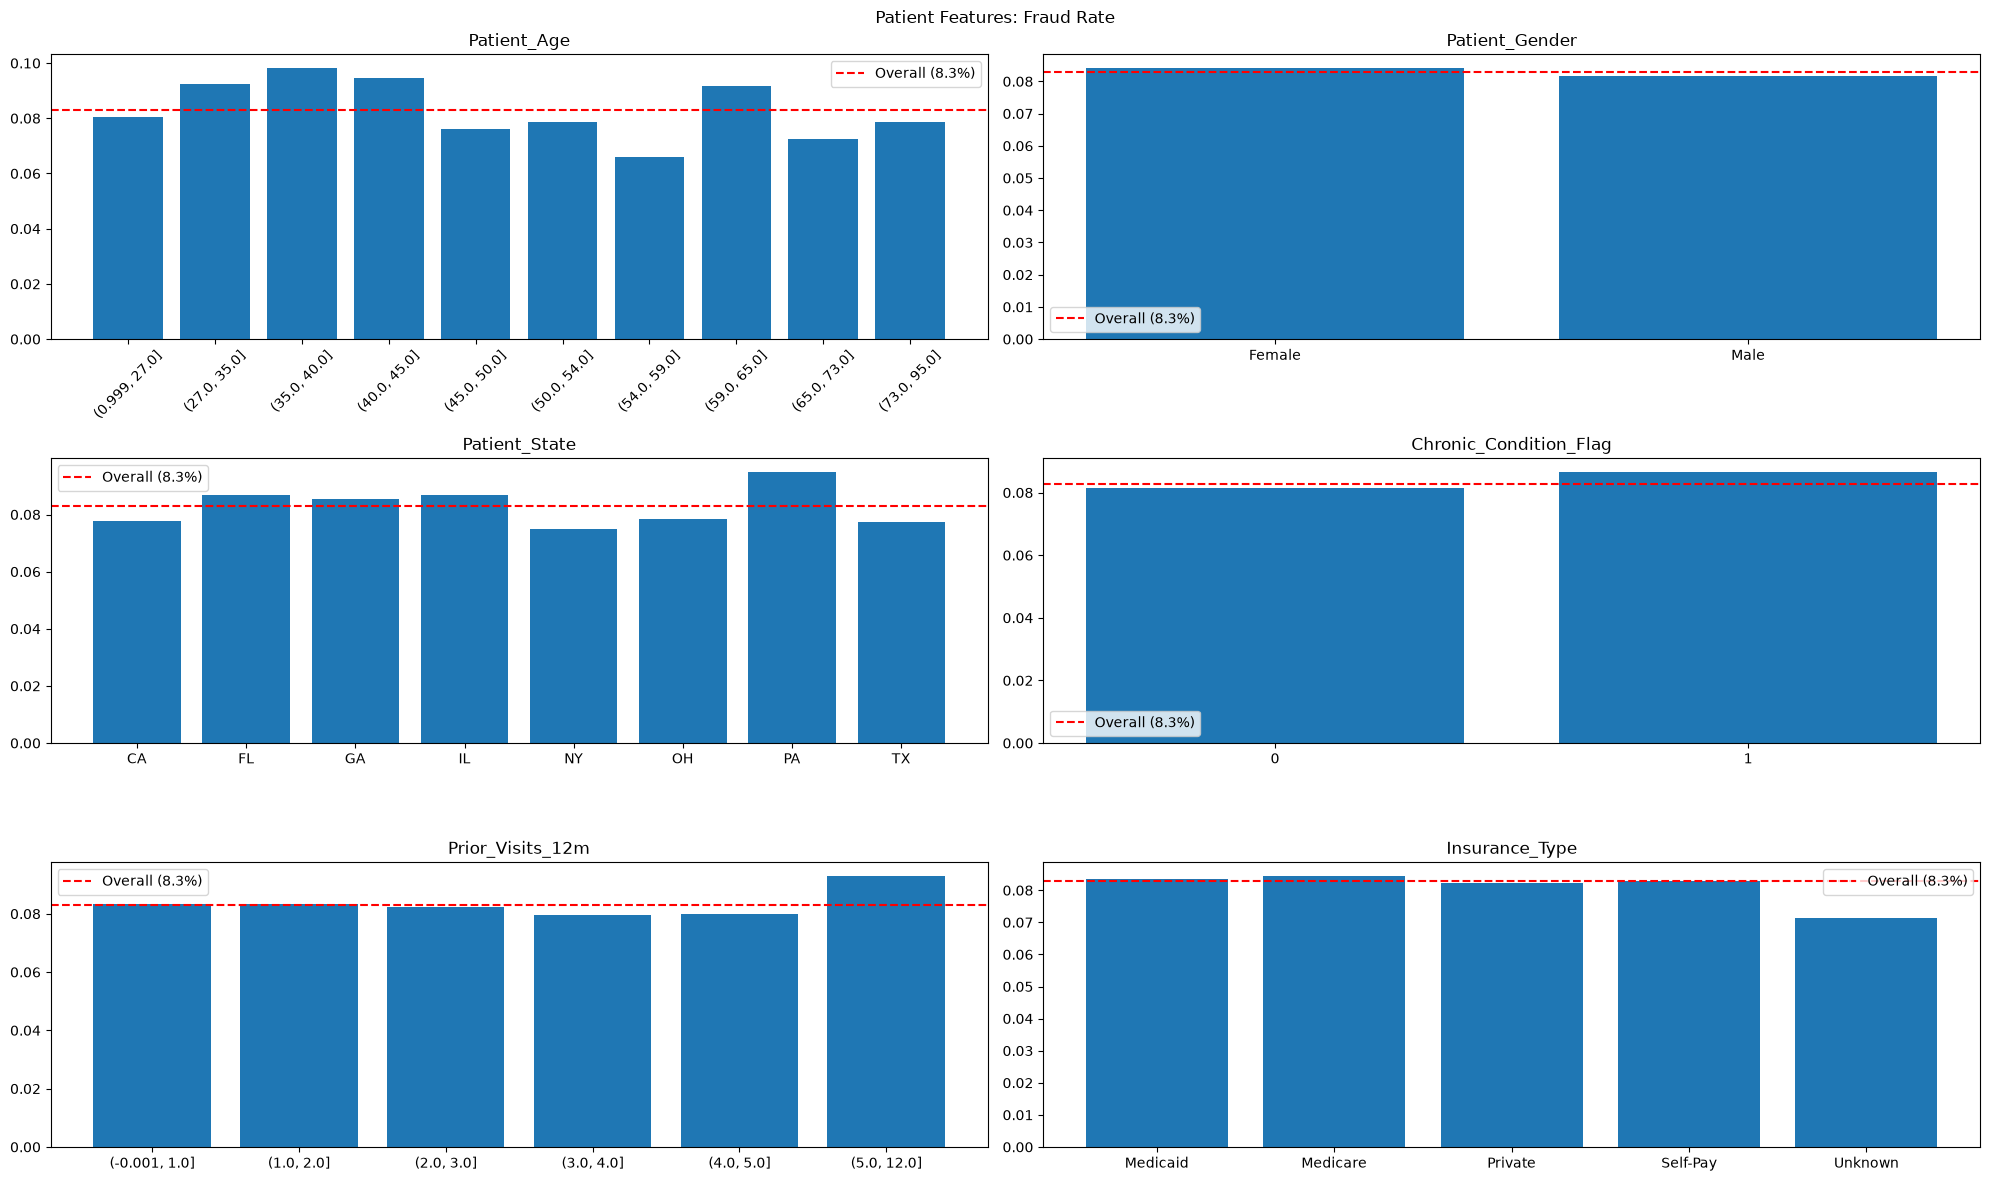

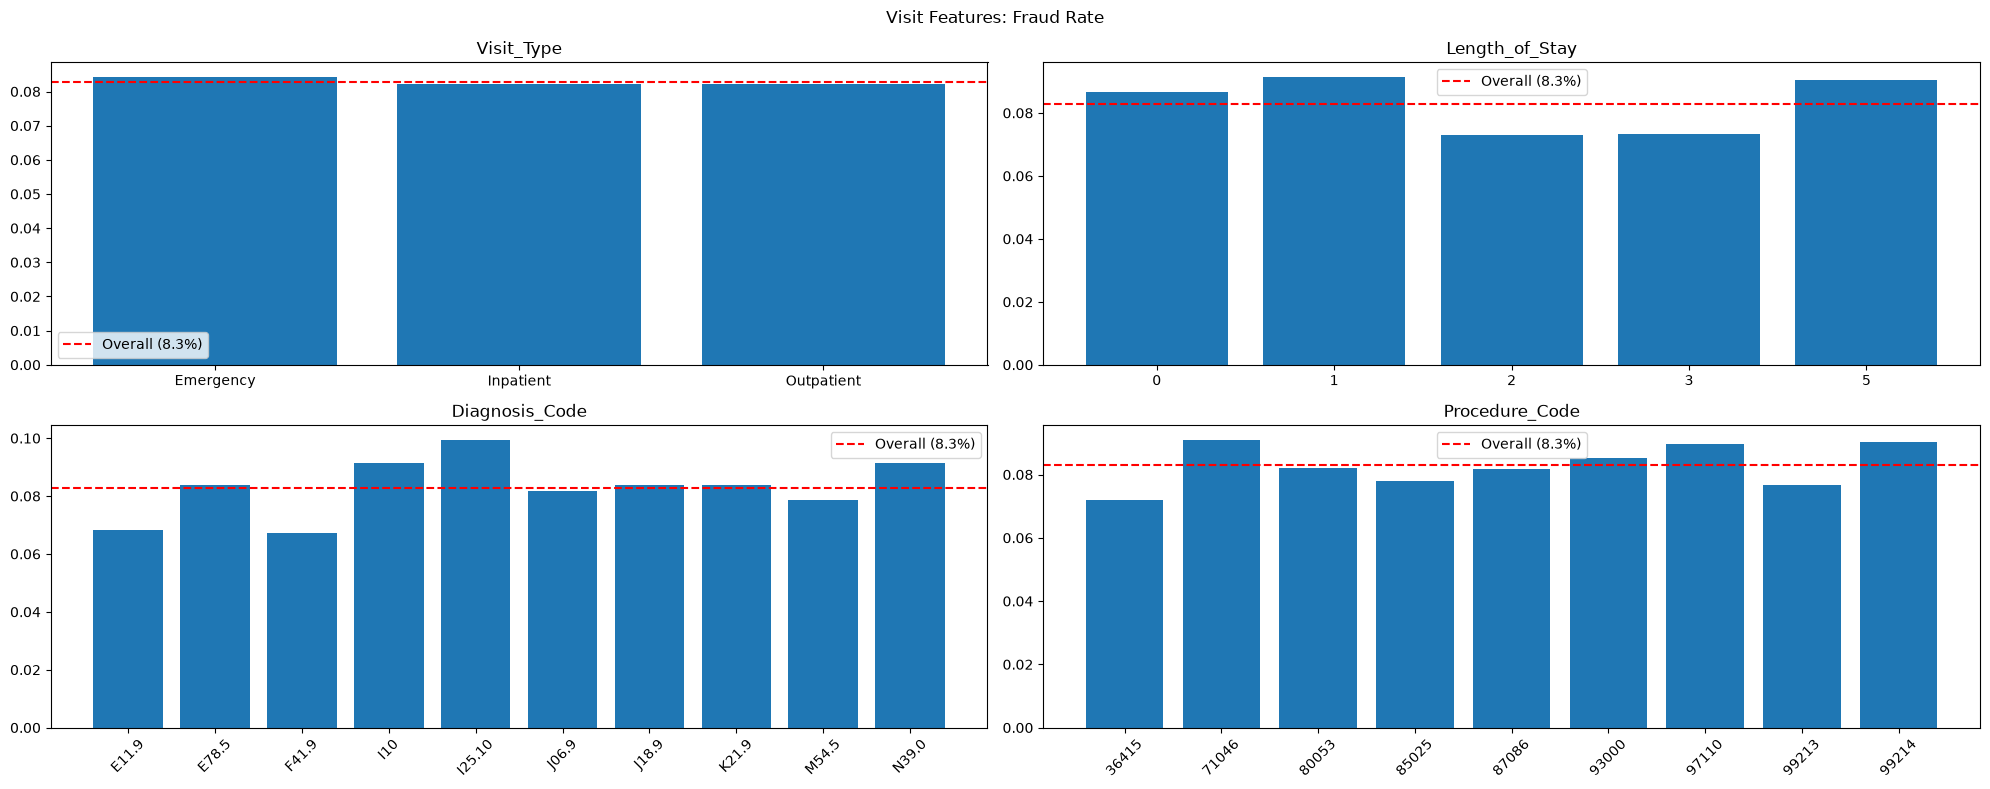

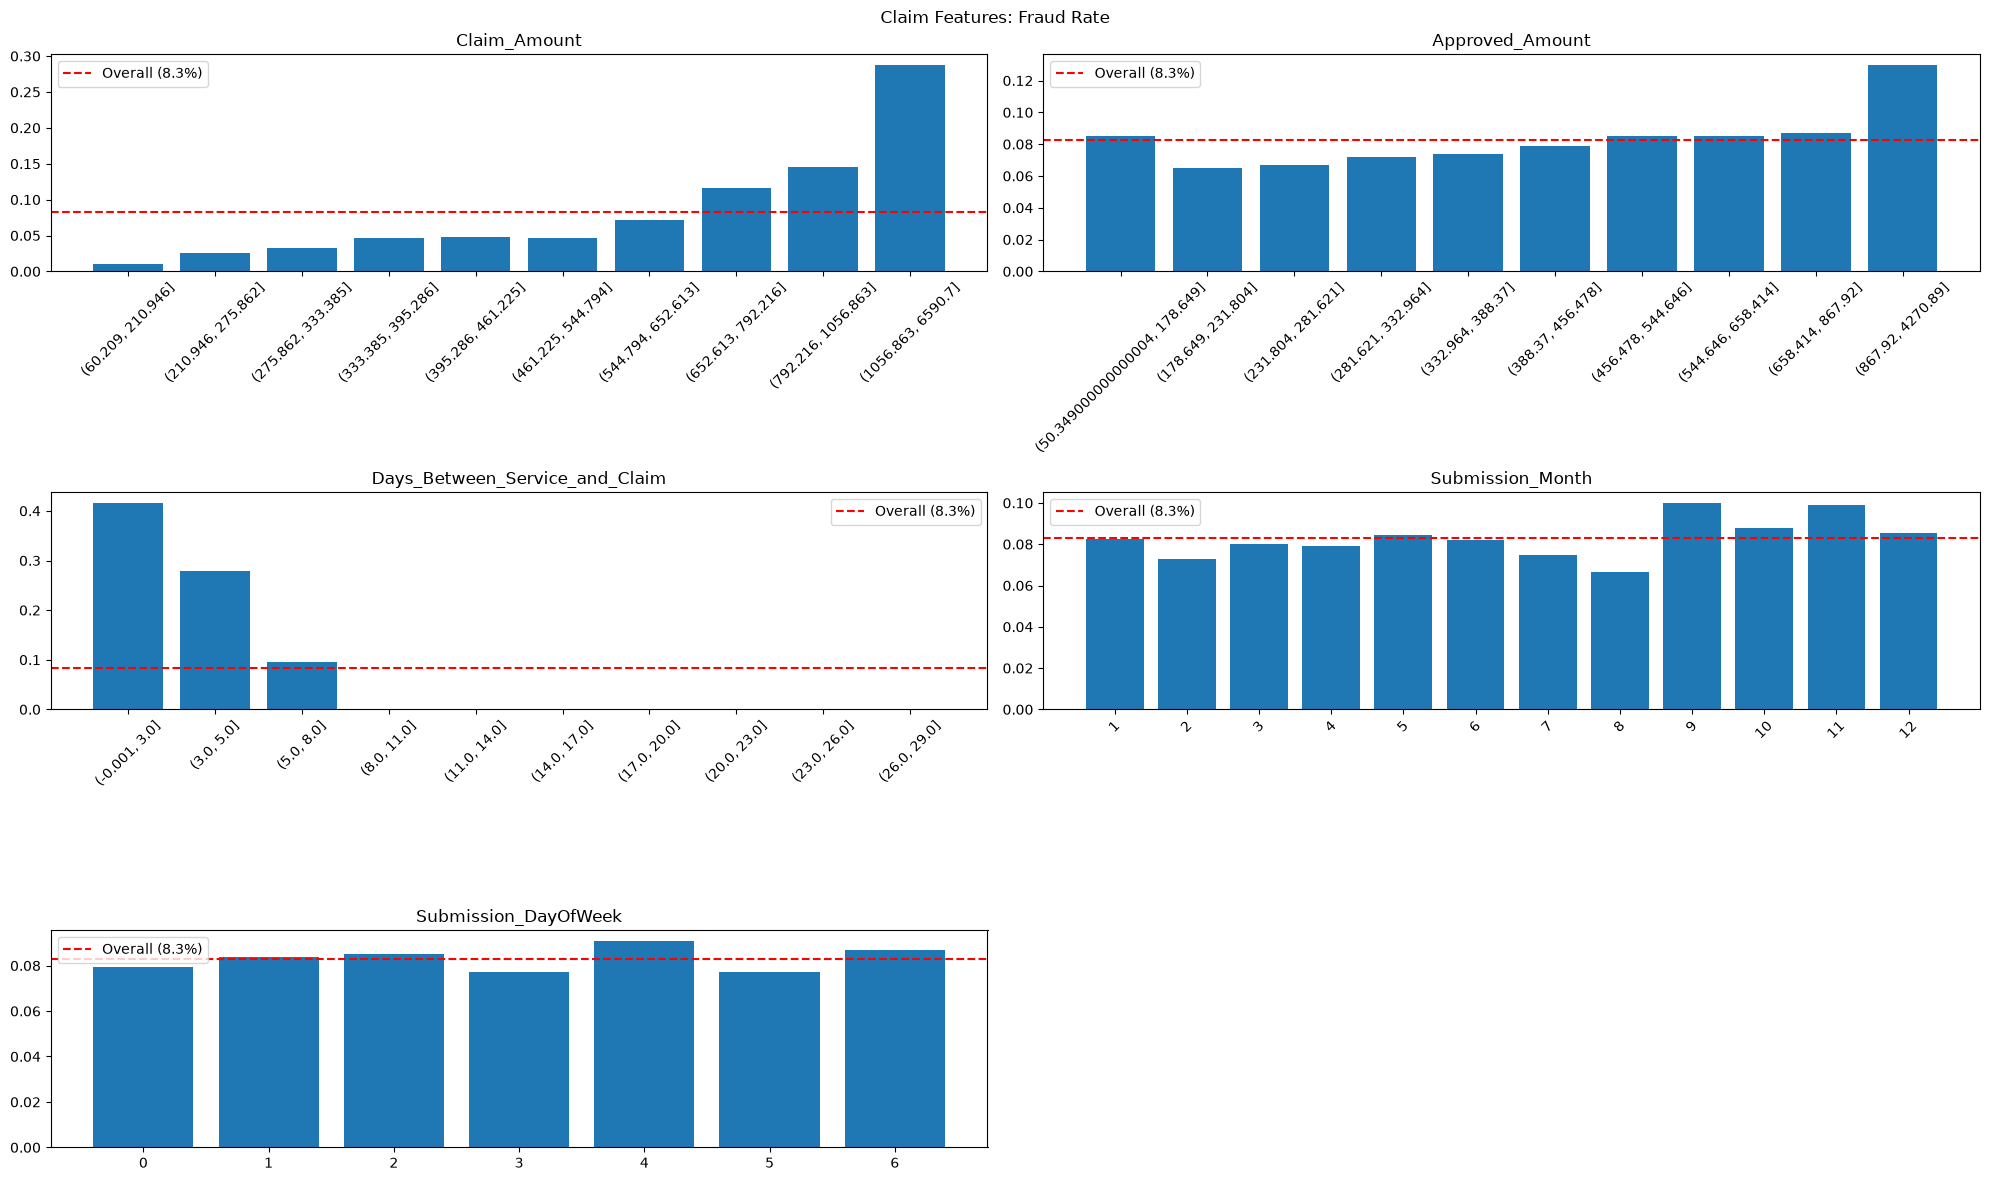

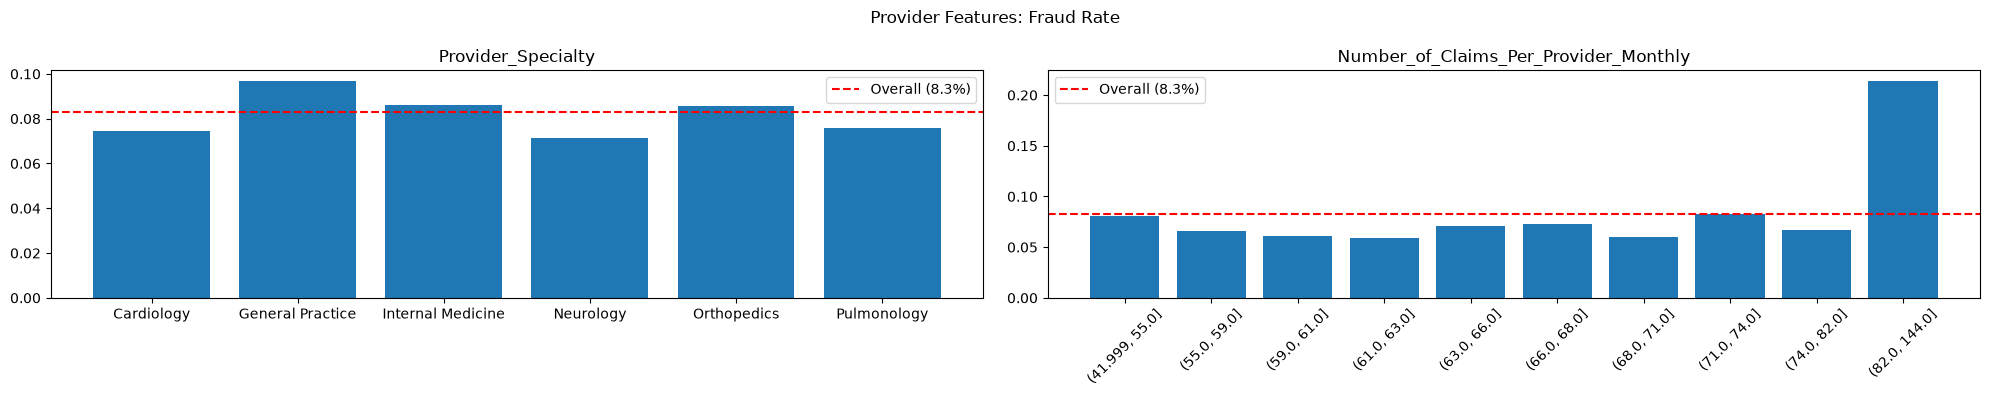

In [26]:
fraud_baseline = df['Is_Fraud'].mean()

def plot_fraud_rates(group_name):
    group_features = features[group_name]
    n = len(group_features)
    rows = (n+1)//2
    fig, axes = plt.subplots(rows, 2, figsize=(20, 4*rows))
    axes = axes.flatten()

    for ax, col in zip(axes, group_features):
        values = df[col]
        # bin values into 10 bins if the values are numeric and there are more than 10 values for that column
        if pd.api.types.is_numeric_dtype(values) and values.nunique() > 12:
            values = pd.qcut(values, q=10, duplicates='drop')

        # groupby - show categories that actually appear in the data
        rates = df.groupby(values, observed=True)['Is_Fraud'].mean()
        # converts labels to text for x-axis labels, draws values in the bars
        ax.bar(rates.index.astype(str), rates.values)
        ax.axhline(fraud_baseline, color='red', linestyle='--', label=f'Overall ({fraud_baseline:.1%})')
        ax.set_title(col)
        if values.nunique() > 8:
            ax.tick_params(axis='x', rotation=45)
        ax.legend()
    for ax in axes.flat[n:]:
        ax.axis('off')

    fig.suptitle(f"{group_name} Features: Fraud Rate", fontsize=12)
    plt.tight_layout()
    plt.show()

for f in features:
    plot_fraud_rates(f)

### EDA Summary: What Separates Fraud from Normal Claims?

Each chart compares a feature's fraud rate against the overall rate of 8.3%. Numeric features with many values are grouped into equal-sized bins.

**Patient features show no meaningful signal.** Age, gender, state, chronic condition, prior visits, and insurance type all sit within about 1.5 percentage points of the 8.3% baseline. Who the patient is doesn't appear to affect fraud.

**Visit features are also flat.** Visit type, length of stay, diagnosis code, and procedure code stay within 1-2% comapred to the baseline, so the kind of care billed isn't a strong fraud indicator on its own.

**Claim features carry the strongest signals:**
- **Claim amount:** Fraud rises steadily with the billed amount, from about 1% in the lowest-billed tenth of claims to about 29% in the highest. 
This makes sense for fraud. Why write small billing claims when inflated ones are more profitable?
- **Filing delay:** The binned chart shows fraud concentrated among claims filed within 1 day after service. This is examined day by day below.
- **Submission month and day of week:** No discernable pattern.
- `Approved_Amount` is shown for reference only. It occurs during claim review, which is after when we need to make a prediction, so this feature is excluded from modeling to avoid leakage.

**Provider features show one strong signal.** Specialty is flat, but providers filing more than 82 claims a month have a fraud rate of about 21%, compared with about 6% to 8% for everyone else. 

High billing volume is a common red flag. This may be done to hide fraud claims from legitimate ones so hospitals/clinics don't notice (insufficient time to manually skim through all the data).

**Takeaway:** Fraud in this dataset is driven by billing behavior (claim amount, filing speed, and provider volume), not by patient or visit characteristics. 

The next two checks look more closely at filing delay and at an unusual pattern in length of stay (no records for length of stay = 4).

### Filing Delay: A Closer Look

In [27]:
print(df.loc[df['Is_Fraud'] == 1, 'Days_Between_Service_and_Claim'].describe())

count    829.000000
mean       2.974668
std        1.973394
min        0.000000
25%        1.000000
50%        3.000000
75%        5.000000
max        6.000000
Name: Days_Between_Service_and_Claim, dtype: float64


All fraud claims were filed within 6 days of service, and no claim filed after that was fraudulent. 

A hard cutoff like this is unusual in real data and suggests the synthetic labels were generated by a rule, so model performance will lean heavily on this feature.

Hence, let's take a look at the fraud rate by individual filing delay (in days) instead of binning them together.

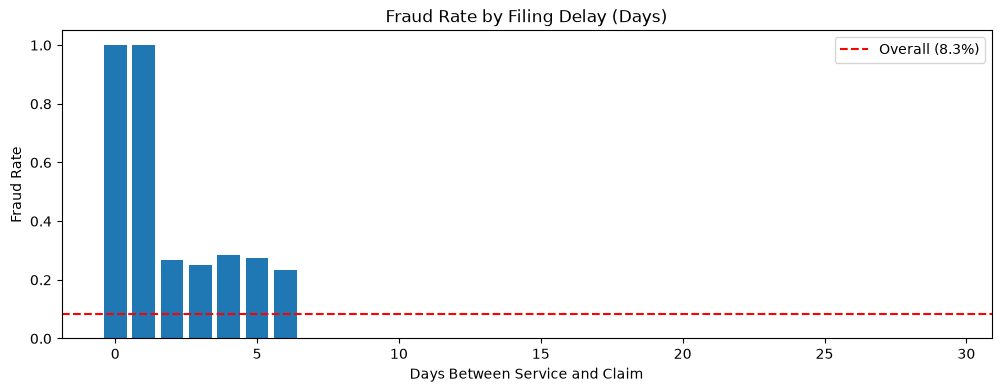

                                 mean  sum  count
Days_Between_Service_and_Claim                   
0                               1.000  115    115
1                               1.000  126    126
2                               0.269  114    424
3                               0.252  119    473
4                               0.284  126    443
5                               0.273  123    451
6                               0.232  106    457
7                               0.000    0    338
8                               0.000    0    311
9                               0.000    0    335


In [28]:
days_stats = df.groupby('Days_Between_Service_and_Claim')['Is_Fraud'].agg(['mean', 'sum', 'count'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(days_stats.index, days_stats['mean'])
ax.axhline(fraud_baseline, color='red', linestyle='--', label=f'Overall ({fraud_baseline:.1%})')
ax.set_xlabel('Days Between Service and Claim')
ax.set_ylabel('Fraud Rate')
ax.set_title('Fraud Rate by Filing Delay (Days)')
ax.legend()
plt.show()

print(days_stats.head(10).round(3))

Filing delay splits claims into three zones: every claim filed within 1 day of service is fraud, claims filed 2 to 6 days after service are about 25% fraud, and no claim filed 7 or more days after service is fraud. 

Rules this sharp don't occur in real billing data, which indicates the synthetic labels were generated from filing delay. 

The modeling challenge is concentrated in the 2-to-6-day window, where other features must distinguish fraud from legitimate claims.

### Length of Stay

In [29]:
df['Length_of_Stay'].value_counts().sort_index()

Length_of_Stay
0    1973
1    2000
2    2028
3    2029
5    1970
Name: count, dtype: int64

Length_of_Stay takes only the values 0, 1, 2, 3, and 5, each with about 2,000 claims, with no stays of exactly 4 days. 

This uniform distribution is unrealistic for hospital stays and is another indication that the dataset is synthetic. The feature shows no relationship with fraud.

### Diagnosis × Procedure Pairs

The dataset only includes codes, so I added plain-English lookups for the diagnosis (ICD-10) and procedure (CPT) codes to make the charts readable. The original code columns are kept for modeling.

In [30]:
diagnosis_lookup = {
    'E11.9': 'Type 2 diabetes',
    'E78.5': 'High cholesterol',
    'F41.9': 'Anxiety disorder',
    'I10': 'High blood pressure',
    'I25.10': 'Coronary artery disease',
    'J06.9': 'Upper respiratory infection',
    'J18.9': 'Pneumonia',
    'K21.9': 'Acid reflux (GERD)',
    'M54.5': 'Low back pain',
    'N39.0': 'Urinary tract infection',
}

procedure_lookup = {
    '36415': 'Blood draw',
    '71046': 'Chest X-ray',
    '80053': 'Comprehensive metabolic panel',
    '85025': 'Complete blood count',
    '87086': 'Urine culture',
    '93000': 'ECG',
    '97110': 'Physical therapy exercise',
    '99213': 'Office visit (low complexity)',
    '99214': 'Office visit (moderate complexity)',
}

df['Diagnosis_Desc'] = df['Diagnosis_Code'].map(diagnosis_lookup)
df['Procedure_Desc'] = df['Procedure_Code'].map(procedure_lookup)

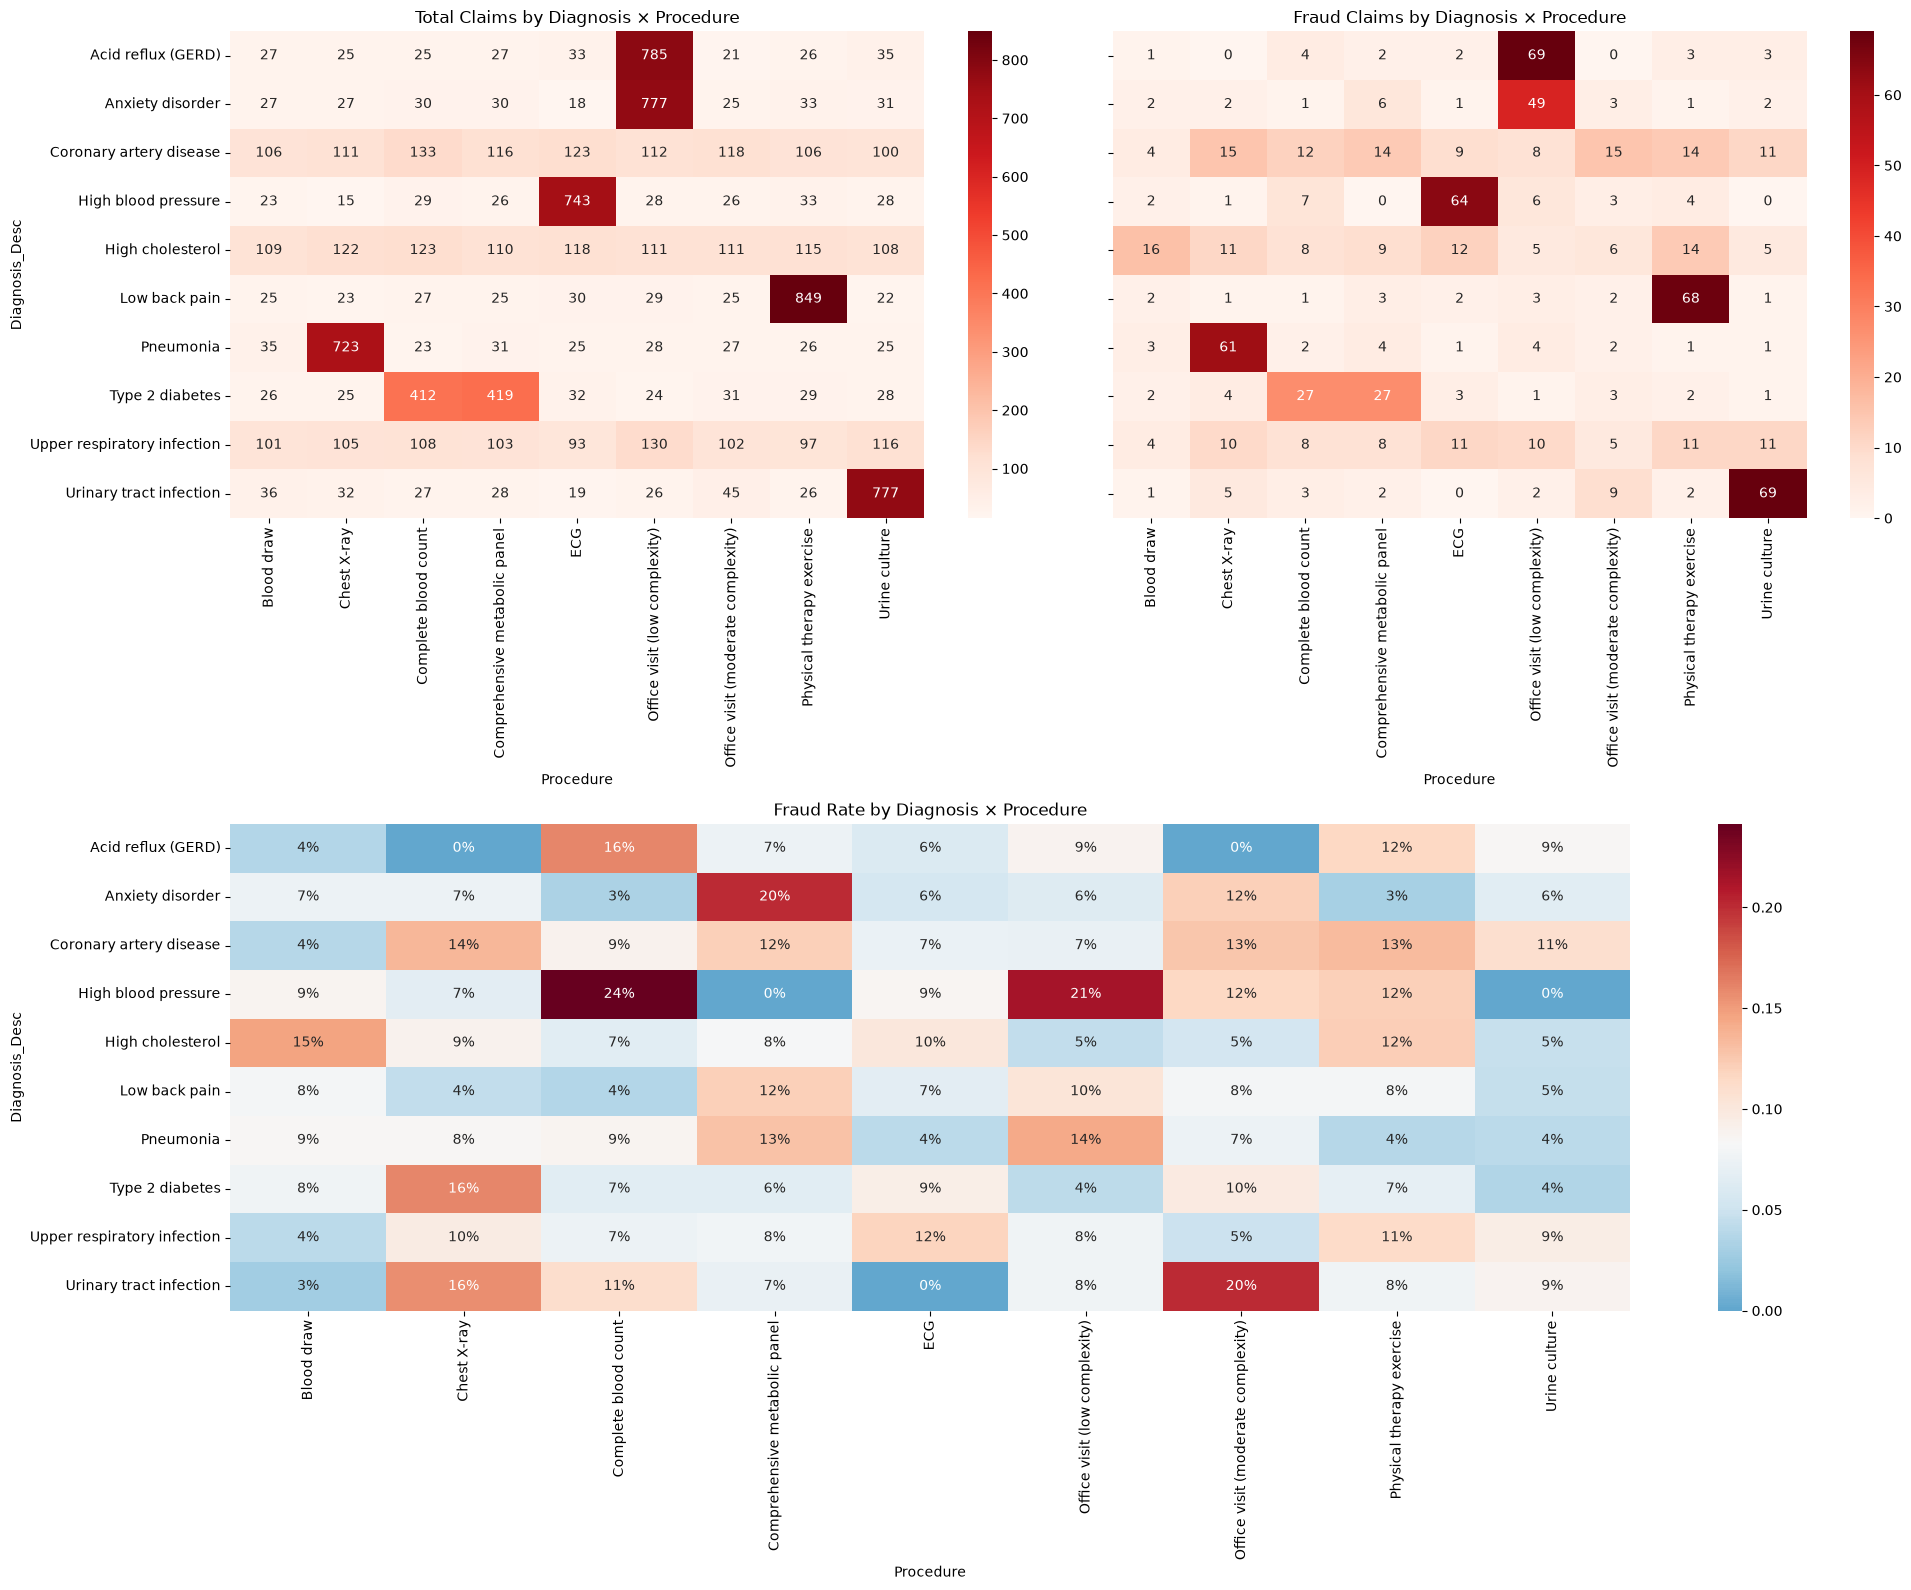

In [31]:
total_counts = pd.crosstab(df['Diagnosis_Desc'], df['Procedure_Desc'])
counts = pd.crosstab(df['Diagnosis_Desc'], df['Procedure_Desc'], values=df['Is_Fraud'], aggfunc='sum')
rates = pd.crosstab(df['Diagnosis_Desc'], df['Procedure_Desc'], values=df['Is_Fraud'], aggfunc='mean')

fig, axes = plt.subplot_mosaic(
    [['total', 'fraud'],
     ['rate',  'rate']],
    figsize=(20, 16)
)

sns.heatmap(total_counts, annot=True, fmt='d', cmap='Reds', ax=axes['total'])
axes['total'].set_title('Total Claims by Diagnosis × Procedure')

sns.heatmap(counts, annot=True, fmt='d', cmap='Reds', ax=axes['fraud'])
axes['fraud'].set_title('Fraud Claims by Diagnosis × Procedure')
axes['fraud'].set_ylabel('')
axes['fraud'].set_yticklabels([])   # labels already shown on the left chart

sns.heatmap(rates, annot=True, fmt='.0%', cmap='RdBu_r',center=fraud_baseline, ax=axes['rate'])
axes['rate'].set_title('Fraud Rate by Diagnosis × Procedure')

for ax in axes.values():
    ax.set_xlabel('Procedure')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Diagnosis × Procedure: Is Mismatched Billing a Fraud Signal?

Billing a procedure that doesn't fit the diagnosis is a classic fraud pattern. 

Three heatmaps test this: total claims (top left), fraud claims (top right), and fraud rate (bottom).

**1. Claim volume follows three patterns (Total Claims).**
- **Seven diagnoses have one dominant procedure** that fits them clinically: 
    - low back pain with physical therapy (849 claims)
    - acid reflux and anxiety with a low-complexity office visit (785 and 777)
    - urinary tract infection with a urine culture (777)
    - high blood pressure with an ECG (743)
    - pneumonia with a chest X-ray (723)
    - type 2 diabetes split between a complete blood count and a metabolic panel (412 and 419). Their other pairings have only 15 to 45 claims each.
- **Three diagnoses are spread evenly**: 
    - Coronary artery disease, high cholesterol, and upper respiratory infection each have roughly 100 to 130 claims per procedure, including clinically unlikely pairings such as a urine culture for coronary artery disease. 
    - Since the data is so evenly spread, this is clearly another sign of synthetic data.

**2. Fraud claims follow claim volume (Fraud Claims).**
Fraud cases are concentrated in the same dominant pairs, simply because that's where most claims are. 

Acid reflux with an office visit and urinary tract infection with a urine culture each have 69 fraud claims.

**3. Reliable rates sit at the baseline; extreme rates come from small cells (Fraud Rate).**
- The large, clinically matched pairs (400 to 850 claims each) all have fraud rates between 6% and 9%, close to the 8.3% overall rate.
- The extreme rates appear only in rare pairs. The highest, 24% for a complete blood count with high blood pressure, is just 7 fraud claims out of 29. The 0% cells are similarly small (19 to 28 claims).
- Clearly mismatched pairs, such as a urine culture for low back pain (5%) or an ECG for a urinary tract infection (0% of 19 claims), show no elevated fraud.

**Conclusion:** 
Unusual fraud rates appear only where sample sizes are too small to be reliable, and mismatched billing shows no elevated fraud. 

Diagnosis-procedure combinations are not a meaningful fraud signal in this dataset.

### Fraud Over Time

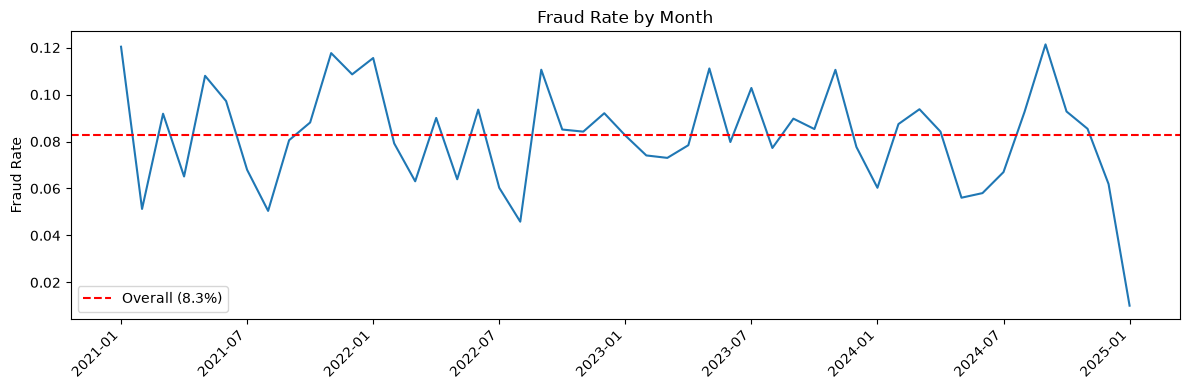

In [32]:
monthly = df.groupby('Month_Year')['Is_Fraud'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(monthly)), monthly.values)
ax.axhline(fraud_baseline, color='red', linestyle='--', label=f'Overall ({fraud_baseline:.1%})')

tick_positions = range(0, len(monthly), 6)
ax.set_xticks(tick_positions)
ax.set_xticklabels(monthly.index[::6], rotation=45, ha='right')

ax.set_title('Fraud Rate by Month')
ax.set_ylabel('Fraud Rate')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
monthly_counts = df.groupby('Month_Year')['Is_Fraud'].agg(['count', 'sum', 'mean'])
monthly_counts.columns = ['Claims_Count', 'Fraud_Count', 'Fraud_Rate']
print(monthly_counts.tail(3))

            Claims_Count  Fraud_Count  Fraud_Rate
Month_Year                                       
2024-11              199           17    0.085427
2024-12              210           13    0.061905
2025-01               99            1    0.010101


Monthly fraud rates fluctuate between about 5% and 12% around the 8.3% baseline, with no trend or seasonal pattern. 

With roughly 200 claims per month, this range is consistent with random variation. The sharp drop in the final month reflects a partial month with few claims. 

Because fraud is stable over time, a random stratified train/test split is appropriate.

## 5. Modeling

### Feature Selection and Train/Test Split

**Which features go in:** every column a fraud model would have when a claim is submitted, except IDs, leaks, and duplicates.
- **Excluded:** `Claim_ID` and `Provider_ID` (IDs), `Claim_Status`, `Approved_Amount`, and `Approval_Ratio` (leakage), `Month_Year` (never repeats for future claims), and `Diagnosis_Desc` and `Procedure_Desc` (duplicate the code columns).
- **Kept, even when EDA showed no signal:** the model can ignore useless features on its own, and dropping them based on EDA would let the test claims (which were part of the EDA) influence my choices.

**Train/test split:** 70% of claims for training and 30% locked away for a final test. `stratify=y` keeps the 8.3% fraud rate in both, so the test set isn't short on fraud cases by bad luck.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import average_precision_score, classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay

In [35]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_to_remove = ['Is_Fraud', 'Claim_Amount', 'Approved_Amount', 'Approval_Ratio']
numeric_cols = [c for c in numeric_cols if c not in numeric_to_remove]

categorical_cols = df.select_dtypes(include=['object', str]).columns.tolist()
categorical_to_remove = ['Claim_ID', 'Provider_ID', 'Claim_Status', 'Month_Year', 'Diagnosis_Desc', 'Procedure_Desc']
categorical_cols = [c for c in categorical_cols if c not in categorical_to_remove]

skewed_cols = ["Claim_Amount"]

feature_cols = numeric_cols + skewed_cols + categorical_cols
X = df[feature_cols]
y = df["Is_Fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
# with stratify y, it split keeps the two test and train groups to have the same characteristics/features
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraud rate: train {y_train.mean():.2%} | test {y_test.mean():.2%}")

Train: (7000, 16) | Test: (3000, 16)
Fraud rate: train 8.29% | test 8.30%


The split gives 7,000 training claims and 3,000 test claims, with fraud rates of 8.29% and 8.30%.

### Preprocessing Pipeline

Each column type gets its own preparation, combined in a `ColumnTransformer`:
- **Numeric columns:** fill missing values with the training median, then scale.
- **Claim amount:** log-transformed, since a few huge claims would otherwise dominate, then scaled.
- **Categories:** fill missing values with "Unknown," then one-hot encode (one yes/no column per category).

Because preprocessing lives inside a pipeline with each model, it's fit on training data only, so no information from the test set leaks in.

In [36]:
numeric_cols_prep = make_pipeline(SimpleImputer(strategy='median', add_indicator=True), StandardScaler())
categorical_cols_prep = make_pipeline(SimpleImputer(strategy='constant', fill_value='Unknown'), OneHotEncoder(handle_unknown='ignore'))
# apply log transform so not to skew the data towards big values; brings small and large values closer together
skewed_cols_prep = make_pipeline(FunctionTransformer(np.log1p), StandardScaler())

preprocess = ColumnTransformer([
    ('numeric', numeric_cols_prep, numeric_cols),
    ('skewed', skewed_cols_prep, skewed_cols),
    ('categorical', categorical_cols_prep, categorical_cols),
])

### Baseline: Simple Logistic Regression

I start with a simple model to see how far a basic approach gets. Logistic Regression gives each feature a weight, adds them up, and turns the total into a probability of fraud. `.predict()` turns each probability into a yes/no answer using a 0.5 cutoff.


Lazy model accuracy: 91.7%
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2751
           1       0.69      0.53      0.60       249

    accuracy                           0.94      3000
   macro avg       0.82      0.76      0.78      3000
weighted avg       0.94      0.94      0.94      3000



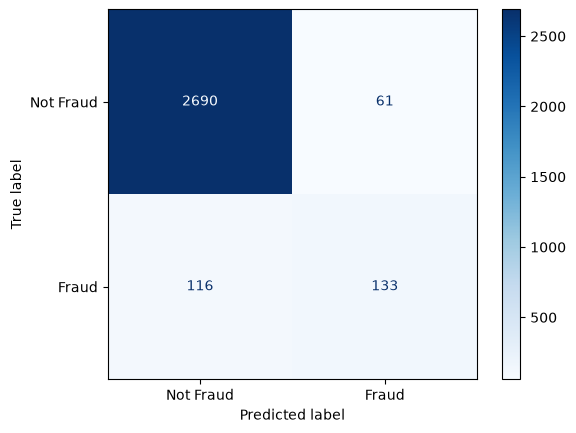

In [37]:
# give 1000 tries to correctly guess each feature's weight
simple_logistic_regression = make_pipeline(preprocess, LogisticRegression(max_iter=1000))
# learn from training data
simple_logistic_regression.fit(X_train, y_train)

# A "lazy" model that says "not fraud" for every claim
lazy_pred = [0] * len(y_test)
print(f"\nLazy model accuracy: {accuracy_score(y_test, lazy_pred):.1%}")

simple_logistic_pred = simple_logistic_regression.predict(X_test)
# print(confusion_matrix(y_test, simple_logistic_pred))
print(classification_report(y_test, simple_logistic_pred))

ConfusionMatrixDisplay.from_predictions(y_test, simple_logistic_pred, display_labels=['Not Fraud', 'Fraud'], cmap='Blues')
plt.show()

### Simple Logistic Regression: Results

**Accuracy is misleading here.** 

The model scores 94% accuracy, but a "lazy" model that labels every claim as not fraud already scores 91.7%, while catching zero fraud. 

Since 92% of claims are normal, accuracy mostly measures how well the model clears easy, normal claims. 

Instead, I focus on the fraud row (1) instead:

- **Precision 0.69:** Of the 194 claims the model flagged, 133 were real fraud. About 7 in 10 flags are correct.
- **Recall 0.53:** Of the 249 real fraud claims, the model caught 133 and **missed 116**, almost half.
- **F1-score 0.60:** Combines precision and recall into one number. It's dragged down by the weak recall.

The normal-claim row (0) looks great (0.96 precision, 0.98 recall), which is why the overall and weighted averages look strong. 

The **macro average** (0.76 recall) gives fraud and normal claims equal say, even though fraud claims are rarer overall.

**Why it misses so much fraud:** During training, the model tries to make as few mistakes as possible, and since normal claims dominate, it plays safe by leaning toward "not fraud." In this case, missing a fraud claim counts the same as a false alarm, even though it actually costs far more.

### Handling the Class Imbalance

In [38]:
counts = y_train.value_counts()
print(counts)
print(f"Ratio (normal ÷ fraud): {counts[0] / counts[1]:.1f}")

Is_Fraud
0    6420
1     580
Name: count, dtype: int64
Ratio (normal ÷ fraud): 11.1


Each fraud mistake counts about 11 times as much as a normal one, so we use a class weighting (`class_weight='balanced'`) to push the model to take fraud seriously.

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      2751
           1       0.38      0.94      0.54       249

    accuracy                           0.87      3000
   macro avg       0.69      0.90      0.73      3000
weighted avg       0.94      0.87      0.89      3000



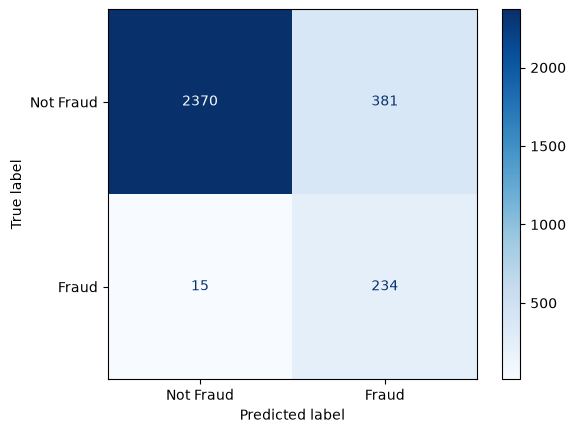

In [39]:
# balance the weighting of the classes, so that both classes are taken into account equally.
weighted_logistic_regression = make_pipeline(preprocess, LogisticRegression(max_iter=1000, class_weight='balanced'))
weighted_logistic_regression.fit(X_train, y_train)
weighted_logistic_pred = weighted_logistic_regression.predict(X_test)

print(classification_report(y_test, weighted_logistic_pred))

ConfusionMatrixDisplay.from_predictions(y_test, weighted_logistic_pred, display_labels=['Not Fraud', 'Fraud'], cmap='Blues')
plt.show()

### Weighted Logistic Regression: Results

Class weighting changed the model's behavior a lot. Comparing the fraud row (1) with the simple model:

| | Simple | Weighted |
|---|---|---|
| **Recall** (fraud caught) | 53% | **94%** |
| **Precision** (flags that are real fraud) | **69%** | 38% |
| **F1-score** | **0.60** | 0.54 |

- **Recall jumped from 53% to 94%.** The model now catches about 234 of the 249 fraud claims, missing only about 15 (down from 116).
- **Precision dropped from 69% to 38%.** To catch that extra fraud, it had to flag more claims (615 claims), thus flagging more false alarms as well (381 were honest claims).

This is the **precision-recall tradeoff**: by casting a wider net, we catch more real fraud claims but also pull in more normal ones.

**Accuracy fell from 94% to 87%,** now below the lazy model's 91.7%, yet this model is far more useful, since it catches almost all fraud. 

Further proof that accuracy is the wrong score here. The **macro-average recall** rose from 0.76 to 0.90, showing the model now handles both classes much more evenly.

A missed fraud claim costs the full payout, while a false alarm costs a review. 

Since missing fraud is usually far more expensive, the weighted model's tradeoff is generally the better one.

### Cross-Validation

So far, each model was judged on one test set, which is one roll of the dice. Cross-validation tests the model on 5 different slices of the **training** data and averages the scores. This is how models are compared and chosen, so the test set stays locked away for one final check.

Across the 5 folds, the weighted Logistic Regression averages **92% recall, 40% precision, and 0.684 PR-AUC**. The scores vary only slightly between folds (± 0.018 for PR-AUC), so the results are stable rather than lucky.

**PR-AUC** (precision-recall area under the curve) scores how well the model *ranks* fraud above normal claims, across every possible cutoff.

In [ ]:
# Cross-validation: we split the training data into 5 folds such that each one keeps the 8.3% fraud rate
# then we shuffle/mix the rows randomly with a fixed seed so results are repeatable.
# Each model trains on 4 folds and is scored on the 5th, for 5 rounds in total.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# To compare models fairly without depending on the 0.5 cutoff, I use the precision-recall curve and PR-AUC next.
scores = cross_validate(weighted_logistic_regression, X_train, y_train, cv=cv, scoring=['precision', 'recall'])
pr_auc = cross_val_score(weighted_logistic_regression, X_train, y_train, cv=cv, scoring='average_precision')
recall_score = scores["test_recall"]
precision_score = scores["test_precision"]

print("Recall per fold:   ", recall_score.round(3))
print("Precision per fold:", precision_score.round(3))
print("PR-AUC per fold:   ", pr_auc.round(3))
print(f"\nAverage recall:     {recall_score.mean():.3f} (± {recall_score.std():.3f})")
print(f"Average precision:  {precision_score.mean():.3f} (± {precision_score.std():.3f})")
print(f"Average PR-AUC:     {pr_auc.mean():.3f} (± {pr_auc.std():.3f})")

Recall per fold:    [0.922 0.914 0.879 0.931 0.966]
Precision per fold: [0.385 0.397 0.385 0.396 0.418]
PR-AUC per fold:    [0.701 0.67  0.665 0.673 0.708]

Average recall:     0.922 (± 0.028)
Average precision:  0.396 (± 0.012)
Average PR-AUC:     0.684 (± 0.018)


### Precision-Recall Curve

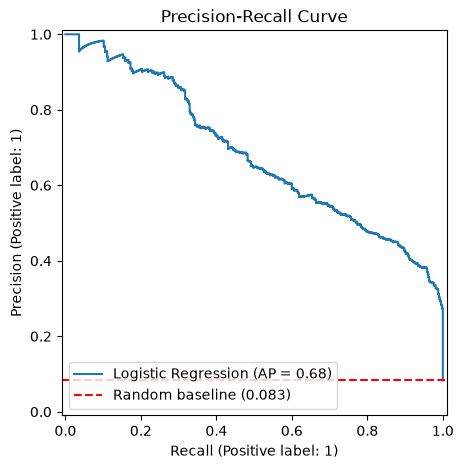

In [41]:
# Get a fraud probability for every training claim, but only from a model that hasn't seen it.
# It splits the training data into 5 folds, trains on 4, predicts the 5th, and rotates until
# every claim has a prediction. [:, 1] keeps just the "fraud" probability.
# This way I can draw the precision-recall curve honestly and keep the test set untouched.
cv_proba = cross_val_predict(weighted_logistic_regression, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_train, cv_proba, ax=ax, name='Logistic Regression')
ax.axhline(y_train.mean(), color='red', linestyle='--', label=f'Random baseline ({y_train.mean():.3f})')
ax.set_title('Precision-Recall Curve')
ax.legend()
plt.show()

In [42]:
tn, fp, fn, tp = confusion_matrix(y_test, weighted_logistic_pred).ravel()
print(f"False alarms: {fp}")
print(f"Share of normal claims (ROC view): {fp / (fp + tn):.1%}")
print(f"Share of flagged claims (PR view): {fp / (fp + tp):.1%}")

False alarms: 381
Share of normal claims (ROC view): 13.8%
Share of flagged claims (PR view): 62.0%


NOTE TO SELF: Both PR and ROC curves track how much fraud the model catches, but ROC measures false alarms against all normal claims (which makes them look small when normal claims dominate), while the PR curve measures them against the claims actually flagged (which shows how much of the reviewers' work is wasted).

### Why a Precision-Recall Curve?

Fraud is only about 8% of claims, which is a severe class imbalance, so I'm using a precision-recall (PR) curve instead of an ROC curve. 

ROC measures false alarms as a share of all normal claims, which make up 92% of the data. 

My weighted Logistic Regression had 381 false alarms, only ~14% of normal claims, so on ROC they look modest. 

However, this made up 62% of the claims it flagged, so most of the reviewers' time would go to honest claims. 
Precision catches that while ROC doesn't.

The PR curve focuses only on fraud. It asks two questions:

- **Precision:** When the model flags a claim, how often is it actually fraud?
- **Recall:** Of all the real fraud, how much does the model catch?

Each point on the curve is a different cutoff.

If we want catch more fraud, we have to accept more false alarms, or flag fewer claims and let more fraud through.

### Reading the Curve

The weighted Logistic Regression scores a **PR-AUC of 0.68**, about 8x the random baseline of 0.083.

- **Top-left:** Precision stays near 100% for the model's most confident flags. These are most likely claims filed within a day of service, which are always fraud in this data.
- **Middle:** As the cutoff loosens, the model starts flagging less certain claims, and precision drops.
- **Right side:** To catch 90% of fraud, precision falls to about 40%.

### What This Means for Cost

The two mistakes don't cost the same. A missed fraud claim costs the full payout, while a false alarm costs a review. 

It's worth accepting extra false alarms to catch more fraud, but only up to the point where the review team gets overwhelmed. 

### Comparing Models

I compare four models on cross-validated PR-AUC, all with class weighting and the same preprocessing:
- **Logistic Regression:** a points system. Each feature adds or subtracts a fixed amount.
- **Decision Tree:** a flowchart of yes/no questions (like 20 Questions).
- **Random Forest:** hundreds of trees, each trained on a slightly different sample, voting together.
- **XGBoost:** trees built one after another, where each new tree focuses on the previous trees' mistakes.

Tree models can capture sudden jumps (like the filing-delay staircase) and "it depends" patterns that a points system can't.

In [43]:
normal_to_fraud_claims_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': weighted_logistic_regression,
    'Decision Tree': make_pipeline(preprocess, DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)),
    # n_jobs=-1 tells the computer to use all of its processor cores at once, so the work finishes faster.
    'Random Forest': make_pipeline(preprocess, RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
    'XGBoost': make_pipeline(preprocess, XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, 
                            scale_pos_weight=normal_to_fraud_claims_ratio, eval_metric='logloss',
                            random_state=42, n_jobs=-1)),
}
scoring = {'PR-AUC': 'average_precision', 'ROC-AUC': 'roc_auc', 'Precision': 'precision', 'Recall': 'recall'}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for metric in scoring:
        row[metric] = scores[f'test_{metric}'].mean()
        row[f'{metric} SD'] = scores[f'test_{metric}'].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).set_index('Model').sort_values('PR-AUC', ascending=False)
print(cv_results[['PR-AUC', 'PR-AUC SD', 'ROC-AUC', 'Precision', 'Recall']].round(3))

                     PR-AUC  PR-AUC SD  ROC-AUC  Precision  Recall
Model                                                             
XGBoost               0.759      0.027    0.967      0.484   0.838
Random Forest         0.686      0.022    0.965      0.619   0.640
Logistic Regression   0.684      0.018    0.959      0.396   0.922
Decision Tree         0.592      0.059    0.957      0.349   0.986


XGBoost has the highest cross-validated PR-AUC (0.759), about 9x the 0.083 baseline. Random Forest and Logistic Regression tie at about 0.68, and the single decision tree trails at 0.59. All four models score about 0.96 on ROC-AUC, which shows why ROC isn't useful for comparing models on imbalanced data.

### Testing the Winner

XGBoost was chosen using cross-validation only. Now it's trained on all 7,000 training claims and evaluated **once** on the locked test set.

Test PR-AUC: 0.759 (baseline 0.083)

              precision    recall  f1-score   support

   Not Fraud       0.98      0.93      0.95      2751
       Fraud       0.49      0.77      0.60       249

    accuracy                           0.91      3000
   macro avg       0.73      0.85      0.77      3000
weighted avg       0.94      0.91      0.92      3000



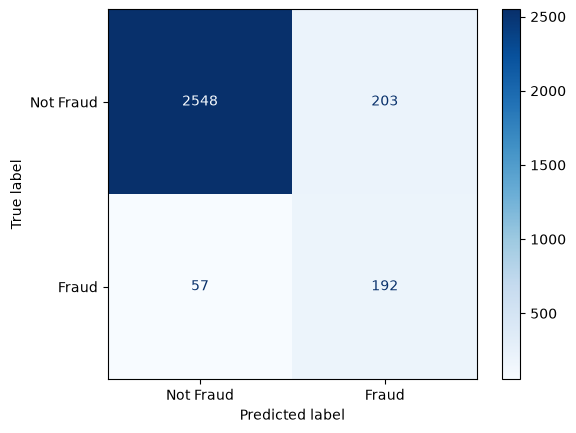

In [44]:
best_model = make_pipeline(
    preprocess,
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                  scale_pos_weight=normal_to_fraud_claims_ratio, eval_metric='logloss', random_state=42, n_jobs=-1)
)
best_model.fit(X_train, y_train)

test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = best_model.predict(X_test)

print(f"Test PR-AUC: {average_precision_score(y_test, test_proba):.3f} (baseline {y_test.mean():.3f})\n")
print(classification_report(y_test, test_pred, target_names=['Not Fraud', 'Fraud']))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=['Not Fraud', 'Fraud'], cmap='Blues')
plt.show()

On the held-out test set, XGBoost scores a PR-AUC of 0.759, matching its cross-validated score of 0.759, so the model generalizes well to unseen claims. 

The model has 77% recall with 49% precision. 

Its accuracy (91%) is slightly below that of a model that never flags fraud (91.7%) --> accuracy is misleading for imbalanced data.

### Honest Check: How Much Does Filing Delay Drive the Model?

In [45]:
# From our EDA, we saw that every claim filed within 1 day is fraud, and none filed after 6 days is.
# Same preprocessing, but without filing delay -- let's see how far the score drops
numeric_no_delay = [c for c in numeric_cols if c != 'Days_Between_Service_and_Claim']
preprocess_no_delay = ColumnTransformer([
    ('numeric', numeric_cols_prep, numeric_no_delay),
    ('skewed', skewed_cols_prep, skewed_cols),
    ('categorical', categorical_cols_prep, categorical_cols),
])

model_no_delay = make_pipeline(
    preprocess_no_delay,
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                  scale_pos_weight=normal_to_fraud_claims_ratio, eval_metric='logloss', random_state=42, n_jobs=-1)
)
model_no_delay.fit(X_train, y_train)
proba_no_delay = model_no_delay.predict_proba(X_test)[:, 1]

print(f"With filing delay:    PR-AUC {average_precision_score(y_test, test_proba):.3f}")
print(f"Without filing delay: PR-AUC {average_precision_score(y_test, proba_no_delay):.3f}")
print(f"Random baseline:      PR-AUC {y_test.mean():.3f}")

With filing delay:    PR-AUC 0.759
Without filing delay: PR-AUC 0.231
Random baseline:      PR-AUC 0.083


PR-AUC dropped from 0.759 to 0.231, so filing delay drives most of the performance. 

The remaining features still score about a little less than 3x the 0.083 baseline, mainly from claim amount and provider volume, which carry real but weaker signal.

### Which Features Matter Most? (Permutation Importance)

For each column, I shuffle its values (breaking its link to fraud) while keeping the other columns untouched, then re-score the model. The bigger the drop in PR-AUC, the more the model relies on that column. The model isn't retrained.

In [46]:
from sklearn.inspection import permutation_importance

# see how much the model depends on each column
# for each permutation, we pick a column and shuffle the values around while keeping the rest untouched
# the shuffling is done 5 times and we record each respective drop.
perm = permutation_importance(best_model, X_test, y_test, scoring='average_precision', n_repeats=5, random_state=42, n_jobs=-1)
# then we get the mean score of the 5 drops
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
print(f"Drops in PR-AUC scores when shuffling data for each feature:\n{importance}")

Drops in PR-AUC scores when shuffling data for each feature:
Procedure_Code                          -0.007136
Submission_DayOfWeek                    -0.005619
Diagnosis_Code                          -0.003550
Prior_Visits_12m                        -0.002983
Submission_Month                        -0.001221
Visit_Type                              -0.000242
Chronic_Condition_Flag                   0.000640
Patient_Gender                           0.000826
Patient_Age                              0.001131
Patient_State                            0.001529
Length_of_Stay                           0.002059
Provider_Specialty                       0.002314
Insurance_Type                           0.002766
Number_of_Claims_Per_Provider_Monthly    0.031848
Claim_Amount                             0.117431
Days_Between_Service_and_Claim           0.654253
dtype: float64


Permutation importance confirms the EDA. Filing delay dominates (shuffling it drops PR-AUC by 0.65), followed by claim amount (0.12) and provider volume (0.03). 

Patient, visit, and date features score about zero, and small negative values reflect noise. 

We can conclude that fraud in this dataset is driven by billing behavior, not by who the patient is or what care they received.

### Tuning XGBoost

A grid search tries every combination of settings (tree depth, learning rate, number of trees, and minimum samples per leaf) and scores each with 5-fold cross-validation.

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

param_grid = {
    'model__max_depth': [2, 3],
    'model__learning_rate': [0.03, 0.05, 0.10],
    'model__n_estimators': [100, 200],
    'model__min_child_weight': [1, 5],
}
def build_pipeline(model):
    return Pipeline([('prep', preprocess), ('model', model)])

grid = GridSearchCV(
    build_pipeline(XGBClassifier(scale_pos_weight=normal_to_fraud_claims_ratio, eval_metric='logloss', random_state=42, n_jobs=-1)),
    param_grid, scoring='average_precision', cv=cv, n_jobs=-1
)
# Try every combination of settings in your grid, scoring each one with 5-fold cross-validation.
grid.fit(X_train, y_train)

untuned = cv_results.loc['XGBoost', 'PR-AUC']
# Get the combination with the best average PR-AUC.
print(f"Best params: {grid.best_params_}")
print(f"Tuned CV PR-AUC: {grid.best_score_:.3f} (untuned: {untuned:.3f}, change: {grid.best_score_ - untuned:+.3f})")

Best params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200}
Tuned CV PR-AUC: 0.790 (untuned: 0.759, change: +0.031)


> **Note to self:** "Noise" = random coincidences in the training data that won't repeat on new claims.

> XGBoost's early trees learn the real patterns (filing delay, claim amount, provider volume). Later trees only have leftover mistakes to fix, and many of those are just random noise. 

> A fast learning rate with lots of trees chases the noise too (overfitting) while a slower rate with fewer trees makes gentler fixes, so it sticks to the real patterns and does better on claims it hasn't seen.

Tuning improved cross-validated PR-AUC from 0.759 to 0.790. Tree depth stayed at 3, but the best settings used a slower learning rate (0.03 instead of 0.1) and fewer trees (200 instead of 300). 

Together, these make the model learn more gently, so each tree makes smaller corrections. This suggests the starting configuration was overfitting, learning noise in the training data. 

Since the fraud signal sits in just a few features (filing delay, claim amount, and provider volume), a gentler model captures it without chasing noise.

### Final Test (Tuned Model)

In [48]:
# Retrain a fresh copy of the pipeline with the winning settings above on the full training set
best_model = grid.best_estimator_
# Get fraud probability for every claim in the test set
test_proba = best_model.predict_proba(X_test)[:, 1]
# Predict each claim to see if they are fraud or not
test_pred =  best_model.predict(X_test) # (test_proba >= 0.5).astype(int)
# Get precision-recall score
test_pr_auc = average_precision_score(y_test, test_proba)
print(f"Test PR-AUC: {test_pr_auc:.3f} (baseline: {y_test.mean():.3f})\n")
print(classification_report(y_test, test_pred, target_names=['Not Fraud', 'Fraud'], digits=3))

Test PR-AUC: 0.798 (baseline: 0.083)

              precision    recall  f1-score   support

   Not Fraud      0.999     0.844     0.915      2751
       Fraud      0.364     0.988     0.532       249

    accuracy                          0.856      3000
   macro avg      0.681     0.916     0.723      3000
weighted avg      0.946     0.856     0.883      3000



### Final Test Results (Tuned XGBoost)

On the held-out test set, the tuned model scores a **PR-AUC of 0.798**, close to its cross-validated 0.790 and up from the untuned model's 0.759. 

Since the test score matches cross-validation, the model generalizes well to claims it hasn't seen.

At the default 0.5 cutoff, the tuned model catches **98.8% of fraud** (246 of 249 claims, missing only 3), but its precision is **36%**: 

it flags about 676 claims, and about 430 of those are honest. Compared with the untuned model (77% recall, 49% precision), the higher PR-AUC means it ranks fraud better, so at any recall level, it delivers more precision than the untuned model. 

The tuned settings just produce softer probabilities, so more claims land above 0.5 (built-in default cutoff).

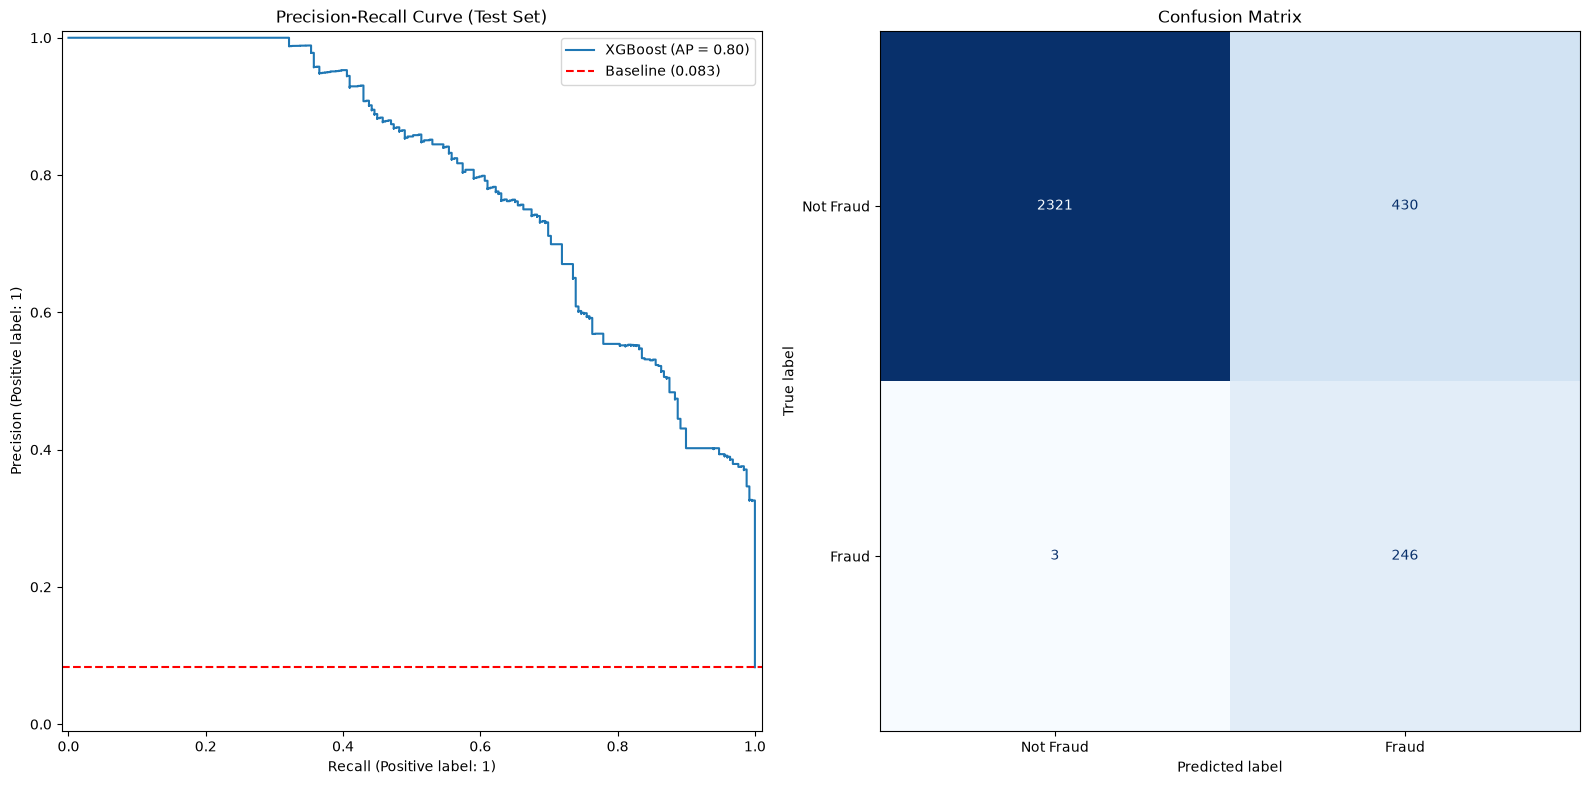

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=ax1, name='XGBoost')
ax1.axhline(y_test.mean(), color='red', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
ax1.set_title('Precision-Recall Curve (Test Set)')
ax1.legend()

ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=['Not Fraud', 'Fraud'], cmap='Blues', colorbar=False, ax=ax2)
ax2.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

The precision-recall curve stays well above the 0.083 baseline across almost every recall level. At the default 0.5 cutoff, the confusion matrix shows the tuned model catching 246 of 249 fraud claims while flagging about 430 honest claims. That cutoff was never chosen for any business reason, so the next step picks one based on cost.

## 6. Choosing a Cutoff by Cost

Every cutoff produces some false alarms and some missed fraud, and both cost money:

> **Total cost = (review cost × claims flagged) + (claim amount of every missed fraud)**

The cutoff is chosen on the training set, using honest cross-validated probabilities, then checked once on the test set. The $50 review cost is an assumption, since the data doesn't include investigation costs.

**Sensitivity check:** Since the $50 review cost is an assumption, I reran the search with other values. The best cutoff rises as reviews get more expensive (0.60 at $25, 0.61 at $50, 0.72 at $100, and 0.81 at $200). When reviews cost more, it's worth flagging fewer claims. The approach holds up, but the exact cutoff should come from the fraud team's real review costs.

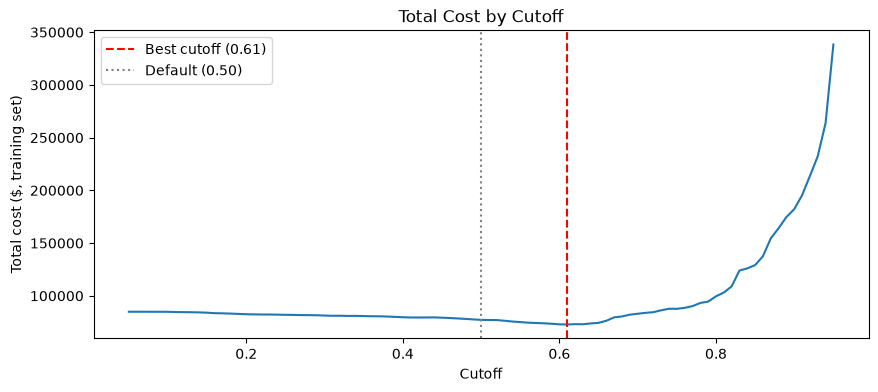

Default         cutoff 0.50 | precision 36.4% | recall 98.8% | flagged 676 | cost $34,322
Cost-optimized  cutoff 0.61 | precision 39.1% | recall 96.0% | flagged 611 | cost $33,611

Review nothing (pay all fraud): $263,151
Review every claim:             $150,000
Review cost $25: best cutoff 0.60
Review cost $50: best cutoff 0.61
Review cost $100: best cutoff 0.72
Review cost $200: best cutoff 0.81


In [ ]:
from sklearn.metrics import precision_score, recall_score
REVIEW_COST = 50   # assume cost to investigate one flagged claim

def total_cost(y_true, proba, amounts, cutoff):
    flagged = proba >= cutoff                        # claims reviewed
    missed = (~flagged) & (y_true == 1)              # false negatives
    return REVIEW_COST * flagged.sum() + amounts[missed].sum()

# 1. Honest probabilities for every training claim (from models that didn't see it)
train_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
train_amounts = X_train['Claim_Amount'].values
y_train_arr = y_train.values

# 2. Try cutoffs from 0.05 to 0.95, and find the cheapest
cutoffs = np.arange(0.05, 0.96, 0.01)
costs = [total_cost(y_train_arr, train_proba, train_amounts, c) for c in cutoffs]
best_cutoff = cutoffs[np.argmin(costs)]

plt.figure(figsize=(10, 4))
plt.plot(cutoffs, costs)
plt.axvline(best_cutoff, color='red', linestyle='--', label=f'Best cutoff ({best_cutoff:.2f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default (0.50)')
plt.xlabel('Cutoff')
plt.ylabel('Total cost ($, training set)')
plt.title('Total Cost by Cutoff')
plt.legend()
plt.show()

# 3. Check the chosen cutoff once on the test set
test_amounts = X_test['Claim_Amount'].values
y_test_arr = y_test.values

for label, c in [('Default', 0.5), ('Cost-optimized', best_cutoff)]:
    pred = (test_proba >= c).astype(int)
    print(f"{label:<15} cutoff {c:.2f} | precision {precision_score(y_test, pred):.1%} | "
          f"recall {recall_score(y_test, pred):.1%} | flagged {pred.sum():,} | "
          f"cost ${total_cost(y_test_arr, test_proba, test_amounts, c):,.0f}")

print(f"\nReview nothing (pay all fraud): ${test_amounts[y_test_arr == 1].sum():,.0f}")
print(f"Review every claim:             ${REVIEW_COST * len(y_test_arr):,.0f}")

for REVIEW_COST in [25, 50, 100, 200]:
    costs = [total_cost(y_train_arr, train_proba, train_amounts, c) for c in cutoffs]
    print(f"Review cost ${REVIEW_COST}: best cutoff {cutoffs[np.argmin(costs)]:.2f}")

In [53]:
print(X_test.loc[y_test == 1, 'Claim_Amount'].mean().astype(float).round(2))

1056.83


I picked the cutoff that gave the lowest total cost on the training data, counting $50 for each review and the full claim amount for each missed fraud.

On the test set, the best cutoff (0.61) flags 611 of 3,000 claims and catches 96% of fraud, for a total cost of **$33,611**. That's 87% cheaper than paying all fraud ($263,151) and 78% cheaper than reviewing every claim ($150,000).

Missing one fraud claim costs about $1,057, or about 21 reviews, so it's worth flagging generously, even if only about 39% of flags turn out to be fraud.